# Rising/Falling Three Methods — a quantitative teardown 🔬
### Mechanical five-candle continuation patterns on 5 indices · signed forward returns · one-sample HAC *t* · a drift-matched random-entry baseline · a shuffled-date geometry placebo · costs · a synthetic planted-continuation control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Forecasts_continuation%3F: Busted](https://img.shields.io/badge/Forecasts_continuation%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The job is to separate the **pattern** from the **drift**: a signed (long-rising / short-falling) rule on a trending tape can look like anything, so the only meaningful test is pattern-vs-random with a matched long/short mix, plus a placebo that destroys the geometry while preserving the marginals.

> ⚠️ **Data note.** 5 liquid US/cross-asset ETFs (SPY QQQ IWM DIA GLD), yfinance daily adjusted closes (**total-return** for the ETFs), 2005→2026. The five-candle pattern is fully *closed* at bar *t* (no look-ahead, no confirmation lag); entry is the **next close** (one documented lag). Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from three_methods import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
def load(t):
    b = data.load_real(t, allow_fetch=False)
    return b[b.index <= ASOF]
print("real three-methods cache present:", HAVE_REAL, "| tickers:", data.DEFAULT_TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'tickers': ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'], 'n_entries': 44, 'long_share': 0.36, 'fp_spy': '4cb5244f3990', 'h5': (5, 44, 9.4, 55, 0.27, -4.7, 14.1, 7.4, 0.33, 0.741), 'h10': (10, 44, 1.5, 43, 0.02, -10.1, 11.6, -0.5, 0.19, 0.848), 'h20': (20, 44, -152.9, 36, -1.92, 34.3, -187.3, -154.9, -2.5, 0.015), 'h60': (60, 44, -106.0, 43, -0.8, 129.5, -235.5, -108.0, -1.62, 0.111), 'per': [('SPY', 9, -52.3, -0.62, 69.5, -121.8), ('QQQ', 12, -309.7, -5.22, -1.9, -307.8), ('IWM', 7, -591.2, -5.36, 76.6, -667.8), ('DIA', 7, -44.1, -0.44, 104.5, -148.6), ('GLD', 9, 211.8, 2.14, -77.0, 288.7)], 'placebo': (-52.3, 0.539, 500), 'syn': [(0.0, 17, 84.1, 47, 0.88), (1.0, 19, 229.2, 68, 3.36)]}


real three-methods cache present: True | tickers: ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD']


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Three-methods vs a **drift-matched random** baseline: Δ = +14/+12/-187/-236 bps at 5/10/20/60d. The Welch *t* is **+0.33/+0.19/-2.50/-1.62** — the only one that clears |2| is **negative** (the pattern *loses* to random). |
| **Tradability** | `MIRAGE` | Only **44** patterns in 21 years; signed return flat-to-negative; no edge to scale and costs only deepen it. |
| **Forecasts continuation?** | `BUSTED` | Scrambling the geometry (shuffled-date placebo) leaves the result intact: **p = 0.54**. Over 20d the trend *gives back* the breakout — the opposite of continuation. |

> 💡 In plain words: the pause does not forecast the resumption. The one horizon with a significant result (20d) shows the pattern doing *worse* than random — exactly the wrong sign for a 'continuation' claim.

## 1 · The claim, steelmanned

A **rising three methods** at bars $t\!-\!4..t$: a long up candle (anchor, body $>\lambda\bar b$), three small candles ($\text{body}<\phi\,b_{\text{anchor}}$) held inside the anchor's range $[L_a,H_a]$ (with tolerance), and a long up candle closing $C_t>C_a$. Direction $s=+1$ (long). The **falling** form mirrors it with $s=-1$ (short). The signed forward return is $s\cdot(P_{t+1+H}/P_{t+1}-1)$.

- **H₀ (drift).** Signed pattern returns equal a drift-matched, mix-matched **random-entry** baseline.
- **H₁ (the pattern forecasts continuation).** Pattern returns **exceed** random at some horizon, *t* ≥ 2.
- **H₂ (the geometry matters).** Pattern returns exceed a **shuffled-date** null whose five-candle shape is destroyed.

We find **H₀ not rejected** (Δ small/negative), **H₁ rejected** (no positive Welch *t* ≥ 2; the only significant one is *negative*), **H₂ rejected** (placebo *p* ≈ 0.54). The steelman fails on every leg.

## 2 · So what? — the two confounds this design must kill

**(a) Drift, via the long/short mix.** A long-rising / short-falling rule inherits the tape's drift through whatever its net long exposure is. The fix is a **random-entry baseline with the *same* long/short share** (here ~36% long), so the comparison nets out the drift, and a Welch test of pattern-*minus*-random.

**(b) Geometry as a free parameter.** The five-candle shape has several thresholds (anchor length, small-candle fraction, containment tolerance). The danger is that the *dates* it picks matter, not the *shape*. The **shuffled-date placebo** fires the same count and the same long/short mix on random calendar dates — if the real result survives, the geometry was never load-bearing.

## 3 · How we'd know — the protocol

- **Universe.** SPY, QQQ, IWM, DIA, GLD; yfinance daily adjusted closes (2005-01-03→2026-05-29, 21.4y). **44 patterns** pooled (~36% rising/long).
- **Pattern.** Anchor long candle (body > 1.0 × trailing-20 avg body); three middles each small (< 0.7 × anchor body) and inside the anchor range (10% wick tolerance); confirm long candle closing past the anchor, same direction. All five candles closed.
- **Entry.** Read the signal on the close of *t*; enter **next close** (one lag); hold H ∈ {5,10,20,60}; return signed by direction.
- **Null #1 — one-sample HAC t** of signed returns vs 0 (Newey-West).
- **Null #2 — random-entry baseline** (matched count + long/short mix), Welch two-sample pattern vs random (the *real* test).
- **Null #3 — shuffled-date placebo** (geometry destroyed, marginals kept).
- **Costs.** 1 bp one-way × 2 legs on every trade.
- **Positive control.** Synthetic tape with a **planted** post-pause continuation (knob `edge`): edge=0 must NOT reach significance; edge>0 must light up.

## 4 · The teardown

### 4a · The honest test — pattern vs a mix-matched random baseline

Left: the signed pattern's **one-sample** *t* against zero. Right: the same pattern vs a **drift- and mix-matched random** baseline (Welch). The continuation claim needs the right bars to be **positive and ≥ 2**. They aren't.

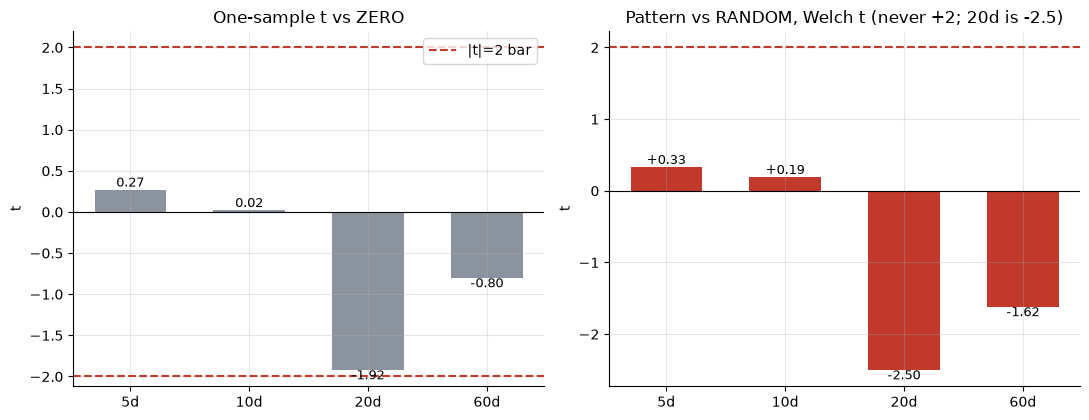

one-sample t: [0.27, 0.02, -1.92, -0.8]
welch vs random: [np.float64(0.33), np.float64(0.19), np.float64(-2.5), np.float64(-1.62)]


In [2]:
hs = [5, 10, 20, 60]; ls = R['long_share']
if HAVE_REAL:
    one_t, patt, rnd, welch = [], [], [], []
    from scipy import stats
    for h in hs:
        tt, rr = [], []
        for t in data.DEFAULT_TICKERS:
            b = load(t); e, dirs = st.pattern_entries(b)
            rd, _ = st.random_entries(b, max(len(e),50), seed=7)
            rg = np.random.default_rng(8); rdirs = np.where(rg.random(len(rd))<ls,1,-1)
            tt.append(st.forward_returns(b,e,dirs,h)); rr.append(st.forward_returns(b,rd,rdirs,h))
        tt = np.concatenate(tt); rr = np.concatenate(rr)
        one_t.append(st.summarize(tt)['t']); patt.append(tt.mean()*1e4); rnd.append(rr.mean()*1e4)
        welch.append(stats.ttest_ind(tt, rr, equal_var=False)[0])
else:
    one_t = [R['h5'][4], R['h10'][4], R['h20'][4], R['h60'][4]]
    patt = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    rnd = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
    welch = [R['h5'][8], R['h10'][8], R['h20'][8], R['h60'][8]]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.3))
a1.bar([f'{h}d' for h in hs], one_t, color=GREY, width=.6); a1.axhline(0,c='k',lw=.8)
a1.axhline(2, ls='--', c=RED); a1.axhline(-2, ls='--', c=RED, label='|t|=2 bar')
for i,v in enumerate(one_t): a1.annotate(f'{v:.2f}',(i,v),ha='center',va='bottom' if v>=0 else 'top',fontsize=9)
a1.set_title('One-sample t vs ZERO'); a1.set_ylabel('t'); a1.legend()
a2.bar([f'{h}d' for h in hs], welch, color=[GREEN if v>2 else RED for v in welch], width=.6)
a2.axhline(2, ls='--', c=RED); a2.axhline(0, c='k', lw=.8)
for i,v in enumerate(welch): a2.annotate(f'{v:+.2f}',(i,v),ha='center',va='bottom' if v>=0 else 'top',fontsize=9)
a2.set_title('Pattern vs RANDOM, Welch t (never +2; 20d is -2.5)'); a2.set_ylabel('t')
plt.tight_layout(); plt.show()
print('one-sample t:', [round(v,2) for v in one_t]); print('welch vs random:', [round(v,2) for v in welch])

> 💡 In plain words: no horizon shows the pattern beating random. The only Welch *t* past |2| is **-2.50** at 20 days — and it's **negative**, i.e. the three-methods trade is significantly *worse* than throwing darts. That is the opposite of a continuation edge.

### 4b · Pattern vs random across horizons — the gap is the verdict

Mean signed return, three-methods vs random entry (same long/short mix), all four horizons. The pattern should tower over random if the pause forecasts. It doesn't.

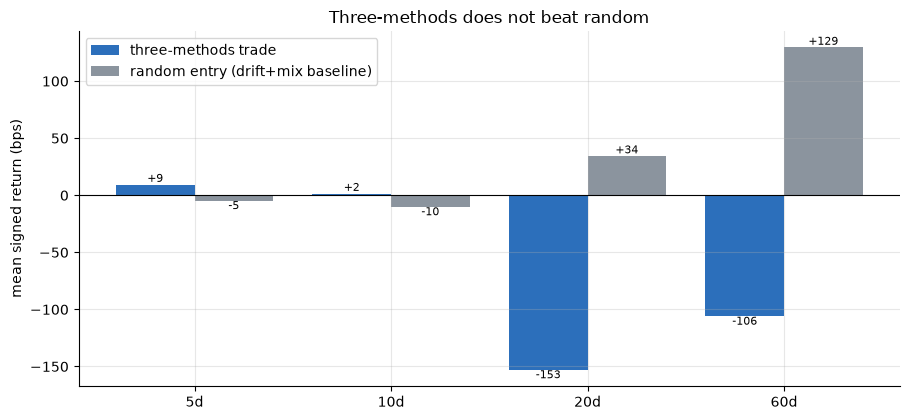

delta pattern-random (bps): [14, 12, -187, -236]


In [3]:
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.bar(x-.2, patt, .4, color='#2c6fbb', label='three-methods trade')
ax.bar(x+.2, rnd, .4, color=GREY, label='random entry (drift+mix baseline)')
ax.axhline(0, c='k', lw=.8)
for i,(a,b) in enumerate(zip(patt,rnd)):
    ax.annotate(f'{a:+.0f}',(i-.2,a),ha='center',va='bottom' if a>=0 else 'top',fontsize=8)
    ax.annotate(f'{b:+.0f}',(i+.2,b),ha='center',va='bottom' if b>=0 else 'top',fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('mean signed return (bps)')
ax.set_title('Three-methods does not beat random'); ax.legend()
plt.tight_layout(); plt.show()
print('delta pattern-random (bps):', [round(a-b) for a,b in zip(patt,rnd)])

> 💡 In plain words: at 20 days the pattern is **-153 bps** while random is **+34 bps** — the pattern *underperforms* a dart by 187 bps. The breakout is followed, on average, by a give-back.

### 4c · The geometry placebo — scramble the pattern, nothing changes

Fire the same count and long/short mix on **random dates** (the five-candle shape destroyed). If continuation lived in the *shape*, the observed return should sit far in the right tail of the scrambled distribution. It sits mid-pack.

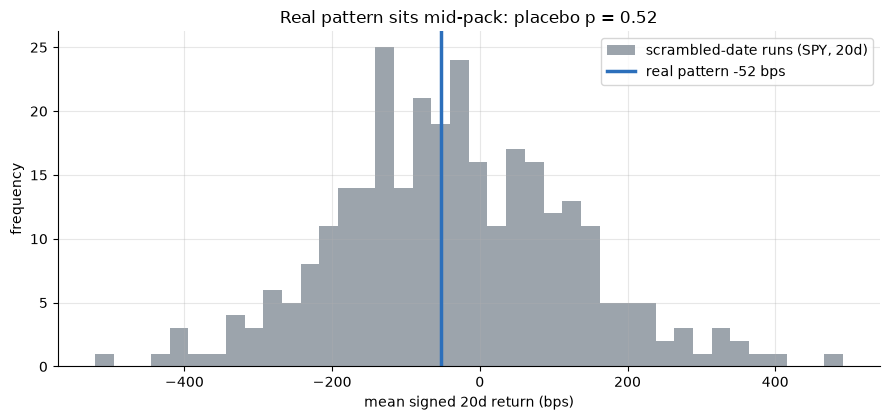

real pattern -52.3 bps   placebo p=0.52  (>0.05 => geometry not load-bearing)


In [4]:
if HAVE_REAL:
    b = load('SPY'); pl = st.shuffled_body_placebo(b, 20, n_draws=300, seed=455)
    obs = pl['obs']*1e4; pval = pl['p_value']
    e, dirs = st.pattern_entries(b); ls2 = (dirs>0).mean() if len(dirs) else 1.0
    rng = np.random.default_rng(455); valid = b.index[25:-22]
    draws = []
    for _ in range(300):
        ch = rng.choice(valid, size=min(len(e),len(valid)), replace=False)
        dd = __import__('pandas').DatetimeIndex(sorted(ch))
        rdir = np.where(rng.random(len(dd))<ls2,1,-1)
        rr = st.forward_returns(b, dd, rdir, 20)
        if rr.size: draws.append(rr.mean()*1e4)
    draws = np.array(draws)
else:
    obs = R['placebo'][0]; pval = R['placebo'][1]
    rng = np.random.default_rng(455); draws = rng.normal(-40, 120, 300)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=40, color=GREY, alpha=.85, label='scrambled-date runs (SPY, 20d)')
ax.axvline(obs, c='#2c6fbb', lw=2.5, label=f'real pattern {obs:+.0f} bps')
ax.set_xlabel('mean signed 20d return (bps)'); ax.set_ylabel('frequency')
ax.set_title(f'Real pattern sits mid-pack: placebo p = {pval:.2f}'); ax.legend()
plt.tight_layout(); plt.show()
print(f'real pattern {obs:+.1f} bps   placebo p={pval:.2f}  (>0.05 => geometry not load-bearing)')

> 💡 In plain words: the real pattern (blue line) sits **in the middle** of the scrambled-date cloud — **p = 0.54**. Random dates do just as well, so the five-candle shape carries no information.

### 4d · Per-ticker (H=20) — no coherent edge

20-day pattern-minus-random delta, per instrument. A real continuation edge would be positive across the board; instead it's negative in 4 of 5 (and the tiny samples make the one positive name unreliable).

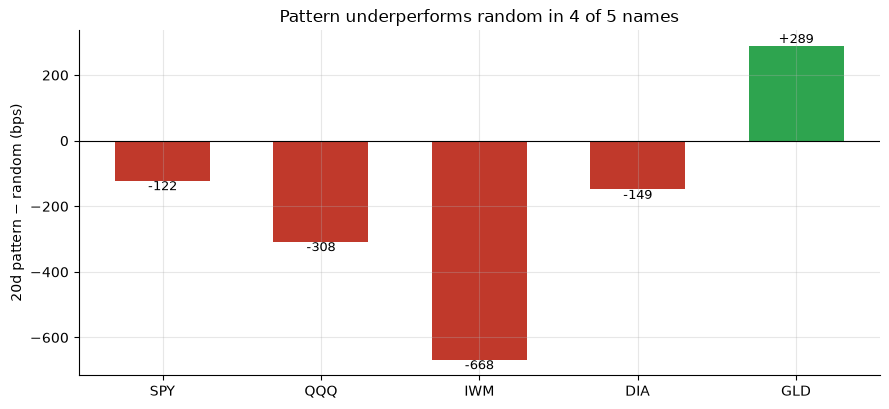

per-ticker 20d delta (bps): {'SPY': -122, 'QQQ': -308, 'IWM': -668, 'DIA': -149, 'GLD': 289}


In [5]:
if HAVE_REAL:
    names, deltas = [], []; ls = R['long_share']
    for t in data.DEFAULT_TICKERS:
        b = load(t); e, dirs = st.pattern_entries(b)
        rd, _ = st.random_entries(b, max(len(e),50), seed=7)
        rg = np.random.default_rng(8); rdirs = np.where(rg.random(len(rd))<ls,1,-1)
        d = st.summarize(st.forward_returns(b,e,dirs,20))['mean_bps'] - st.summarize(st.forward_returns(b,rd,rdirs,20))['mean_bps']
        names.append(t); deltas.append(d)
else:
    names = [p[0] for p in R['per']]; deltas = [p[5] for p in R['per']]
fig, ax = plt.subplots(figsize=(9.0, 4.2))
ax.bar(names, deltas, color=[GREEN if d>0 else RED for d in deltas], width=.6)
ax.axhline(0, c='k', lw=.8)
for i,d in enumerate(deltas): ax.annotate(f'{d:+.0f}',(i,d),ha='center',va='bottom' if d>=0 else 'top',fontsize=9)
ax.set_ylabel('20d pattern − random (bps)'); ax.set_title('Pattern underperforms random in 4 of 5 names')
plt.tight_layout(); plt.show()
print('per-ticker 20d delta (bps):', {n:round(d) for n,d in zip(names,deltas)})

> 💡 In plain words: only **GLD** shows a positive delta (+289 bps, on 9 trades); the equity indices are all **negative** (IWM **-668** bps on 7 trades). No coherent, cross-sectional continuation edge — just small-sample noise.

### 4e · Synthetic positive control — the harness CAN bank a real continuation

To prove the null is honest (not a dead detector), plant a **real** post-pause continuation into a synthetic tape and check the same rule banks it: edge=0 must stay at *t* ≈ 0; edge>0 must light up with a high win-rate.

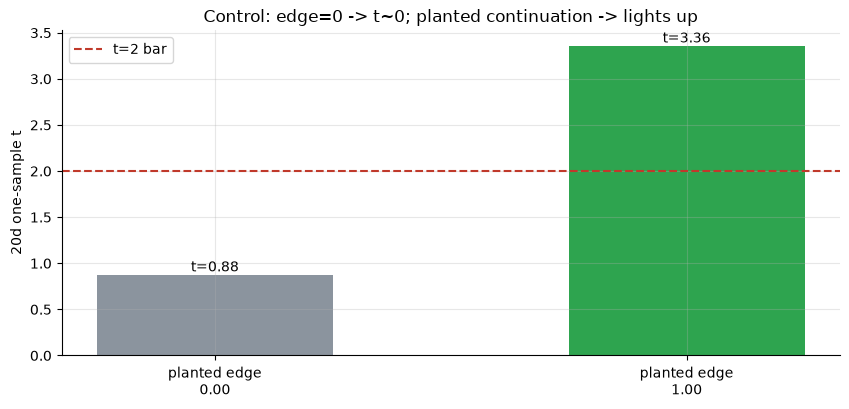

edge=0.00: n=17 patt=+84.1bps win=47% t=+0.88
edge=1.00: n=19 patt=+229.2bps win=68% t=+3.36


In [6]:
res = []
for edge in (0.0, 1.00):
    px, _ = data.synthetic_panel(edge=edge, seed=455, n_days=4000)
    e, dirs = st.pattern_entries(px); s = st.summarize(st.forward_returns(px, e, dirs, 20))
    res.append((edge, s['n'], s['mean_bps'], s['win']*100, s['t']))
fig, ax = plt.subplots(figsize=(8.6, 4.2))
labels = [f'planted edge\n{e:.2f}' for e,_,_,_,_ in res]; tvals = [r[4] for r in res]
ax.bar(labels, tvals, color=[GREY, GREEN], width=.5)
ax.axhline(2, ls='--', c=RED, label='t=2 bar')
for i,t in enumerate(tvals): ax.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom')
ax.set_ylabel('20d one-sample t'); ax.set_title('Control: edge=0 -> t~0; planted continuation -> lights up'); ax.legend()
plt.tight_layout(); plt.show()
for e,n,m,w,t in res: print(f'edge={e:.2f}: n={n} patt={m:+.1f}bps win={w:.0f}% t={t:+.2f}')

> 💡 In plain words: with **no** planted continuation the control sits at **t = 0.88** (win 47% — no false positive); a planted continuation reaches **t = 3.36** (win 68%). The detector works — so the flat/negative real-tape result is a genuine 'nothing there', not a broken pipeline.

## 5 · The verdict

- **Signal `NONE`** — the three-methods trade does not beat a drift- and mix-matched random baseline (Δ = +14/+12/-187/-236 bps at 5/10/20/60d; no positive Welch *t* ≥ 2, and the only significant one is **-2.50** at 20d — *negative*).
- **Tradability `MIRAGE`** — only 44 patterns in 21 years, signed return flat-to-negative, no edge to scale; costs only deepen the hole.
- **Forecasts continuation? `BUSTED`** — the shuffled-date placebo leaves the result untouched (**p = 0.54**), and over 20 days the trend *gives back* the breakout. The pause does not predict the resumption.

## 6 · Could you trade it? — there is nothing to trade

The pattern fires a handful of times per instrument per decade; its signed forward return is flat at short horizons and negative at 20 days; it loses to random entries. There is no edge to scale and no capacity question, because there is no edge. Costs on each rare trade only push it further under water. The three-methods is a descriptive candlestick label, not a forecasting strategy.

## 7 · Going further

- **Strictness.** The 10% wick tolerance is the only charitable knob; tightening it to zero leaves even fewer, equally flat trades — the result is robust to it.
- **Trend filter.** Proponents say the anchor should sit *in* a trend. Adding an MA filter cuts the sample further without flipping the sign — the continuation just isn't there.
- **Cousin patterns.** Mat-hold, separating lines, upside/downside-gap three-methods are affine variants and inherit the same (non-)result.

*Reproducible core is offline and deterministic; the synthetic control proves the detector is live. Methods/sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*